In [ ]:
import pandas as pd
import os
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier  
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split
import joblib

In [2]:
root_dir = 'C:/Users/MELİSA/Desktop/flowmeter_labeled_data.csv'
df = pd.read_csv(root_dir)

In [3]:
df.shape

(27809999, 85)

In [4]:
df.columns

Index(['Flow ID', 'Src IP', 'Src Port', 'Dst IP', 'Dst Port', 'Protocol',
       'Timestamp', 'Flow Duration', 'Total Fwd Packet', 'Total Bwd packets',
       'Total Length of Fwd Packet', 'Total Length of Bwd Packet',
       'Fwd Packet Length Max', 'Fwd Packet Length Min',
       'Fwd Packet Length Mean', 'Fwd Packet Length Std',
       'Bwd Packet Length Max', 'Bwd Packet Length Min',
       'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s',
       'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max',
       'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std',
       'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean',
       'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags',
       'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length',
       'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s',
       'Packet Length Min', 'Packet Length Max', 'Packet Length Mean',
       'Packet Length Std', 'Packet Len

In [9]:
df = df.drop(columns="Label")

In [10]:
df.head()

,Flow ID,Src IP,Src Port,Dst IP,Dst Port,Protocol,Timestamp,Flow Duration,Total Fwd Packet,Total Bwd packets,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Attack_Type
0,192.168.137.41-157.249.81.141-51746-80-6,192.168.137.41,51746,157.249.81.141,80,6,07/10/2022 02:15:01 PM,291959,5,4,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign&Bruteforce_benign
1,192.168.137.41-157.249.81.141-50096-443-6,192.168.137.41,50096,157.249.81.141,443,6,07/10/2022 02:15:01 PM,291320,5,4,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign&Bruteforce_benign
2,192.168.137.41-157.249.81.141-51749-80-6,192.168.137.41,51749,157.249.81.141,80,6,07/10/2022 02:15:03 PM,292739,5,4,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign&Bruteforce_benign
3,192.168.137.41-157.249.81.141-50099-443-6,192.168.137.41,50099,157.249.81.141,443,6,07/10/2022 02:15:03 PM,292398,5,4,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign&Bruteforce_benign
4,192.168.137.41-157.249.81.141-51752-80-6,192.168.137.41,51752,157.249.81.141,80,6,07/10/2022 02:15:04 PM,293252,5,4,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign&Bruteforce_benign


In [4]:
label_counts = df["Attack_Type"].value_counts()
label_counts

Attack_Type
DoS_DoS SYN Flood               16290644
DoS_DoS-UDP_Flood                5210536
DDoS_DDoS ACK Fragmentation      2450086
DoS_DoS-HTTP_Flood               1642744
DDoS_DDoS-HTTP Flood              505720
VulnerabilityScan                 442158
Benign&Bruteforce_benign          398330
DDoS_DDoS-ICMP_Fragmentation      320757
DDoS_DDoS ICMP Flood              202251
Mirai                             174588
spoofing_ARP Spoofing              82382
spoofing_DNS Spoofing              74856
sqlinjection                        6603
Benign&Bruteforce_BruteForce        3619
XSS                                 3377
Uploading_Attack                    1348
Name: count, dtype: int64

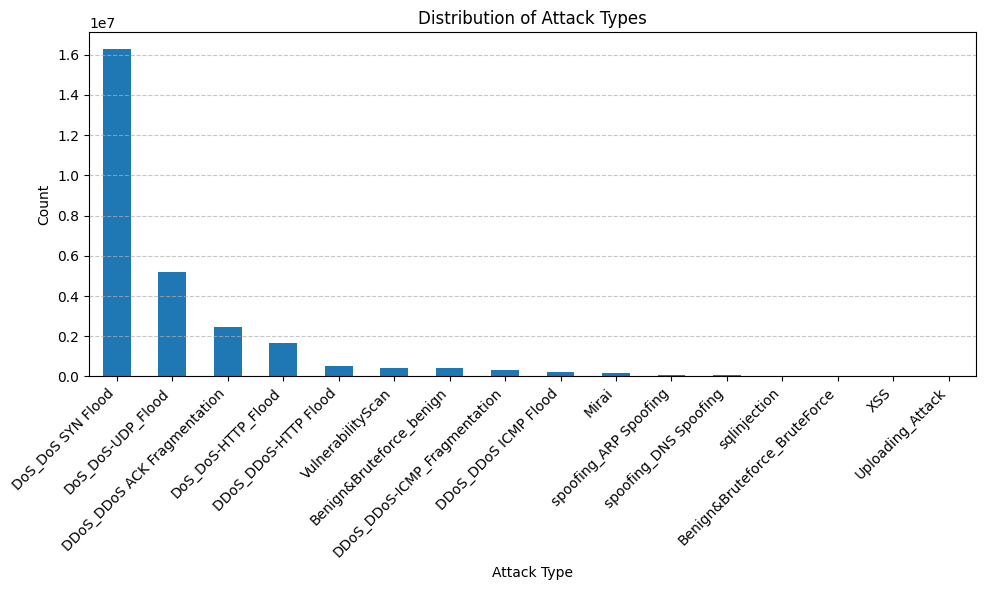

In [ ]:
import matplotlib.pyplot as plt


label_counts = df["Attack_Type"].value_counts()

plt.figure(figsize=(10,6))
label_counts.plot(kind='bar')
plt.title('Distribution of Attack Types')
plt.xlabel('Attack Type')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


In [ ]:
from sklearn.model_selection import train_test_split


df_filtered = df[df["Attack_Type"] != "Benign&Bruteforce_benign"]


df_small, _ = train_test_split(df_filtered, test_size=0.99, stratify=df_filtered["Attack_Type"], random_state=42)


print(df_small["Attack_Type"].value_counts())


Attack_Type
DoS_DoS SYN Flood               162906
DoS_DoS-UDP_Flood                52105
DDoS_DDoS ACK Fragmentation      24501
DoS_DoS-HTTP_Flood               16427
DDoS_DDoS-HTTP Flood              5057
VulnerabilityScan                 4422
DDoS_DDoS-ICMP_Fragmentation      3208
DDoS_DDoS ICMP Flood              2022
Mirai                             1746
spoofing_ARP Spoofing              824
spoofing_DNS Spoofing              749
sqlinjection                        66
Benign&Bruteforce_BruteForce        36
XSS                                 34
Uploading_Attack                    13
Name: count, dtype: int64


In [13]:
df_small.shape

(274116, 85)

In [ ]:
from sklearn.model_selection import train_test_split


df_smaller, _ = train_test_split(df_small, test_size=0.85, stratify=df_small["Attack_Type"], random_state=42)


print(df_smaller["Attack_Type"].value_counts())


Attack_Type
DoS_DoS SYN Flood               24436
DoS_DoS-UDP_Flood                7816
DDoS_DDoS ACK Fragmentation      3675
DoS_DoS-HTTP_Flood               2464
DDoS_DDoS-HTTP Flood              759
VulnerabilityScan                 663
DDoS_DDoS-ICMP_Fragmentation      481
DDoS_DDoS ICMP Flood              303
Mirai                             262
spoofing_ARP Spoofing             124
spoofing_DNS Spoofing             112
sqlinjection                       10
XSS                                 5
Benign&Bruteforce_BruteForce        5
Uploading_Attack                    2
Name: count, dtype: int64


In [18]:
df_smaller.shape

(41117, 85)

In [19]:
benign_df = df[df["Attack_Type"] == "Benign&Bruteforce_benign"]

In [20]:
benign_df.shape

(398330, 85)

In [21]:
df_smaller_with_benign = pd.concat([df_smaller, benign_df], ignore_index=True)

In [23]:
df_smaller_with_benign.shape

(439447, 85)

In [24]:
label_counts = df_smaller_with_benign["Attack_Type"].value_counts()
label_counts

Attack_Type
Benign&Bruteforce_benign        398330
DoS_DoS SYN Flood                24436
DoS_DoS-UDP_Flood                 7816
DDoS_DDoS ACK Fragmentation       3675
DoS_DoS-HTTP_Flood                2464
DDoS_DDoS-HTTP Flood               759
VulnerabilityScan                  663
DDoS_DDoS-ICMP_Fragmentation       481
DDoS_DDoS ICMP Flood               303
Mirai                              262
spoofing_ARP Spoofing              124
spoofing_DNS Spoofing              112
sqlinjection                        10
XSS                                  5
Benign&Bruteforce_BruteForce         5
Uploading_Attack                     2
Name: count, dtype: int64

In [ ]:
df_smaller_with_benign.to_csv("smaller_dataset.csv", index=False)
